# 로지스틱 회귀

## 데이터 준비

In [1]:
import pandas as pd

In [2]:
fish = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/fish_data.csv')

In [3]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
import numpy as np

In [5]:
np.unique(fish['Species'], return_counts=True)

(array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
       dtype=object),
 array([35, 11, 56, 17, 20, 14,  6]))

In [6]:
fish.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')

In [7]:
fish_target = fish['Species'].to_numpy()
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

In [8]:
print(fish_input.shape, fish_target.shape)

(159, 5) (159,)


In [9]:
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
ss = StandardScaler()
ss.fit(fish_input)
fish_scaled = ss.transform(fish_input)

In [12]:
print(fish_scaled)

[[-4.38072172e-01 -2.82303007e-01 -1.06020232e-01  5.96578670e-01
  -2.36528948e-01]
 [-3.03562184e-01 -1.98053663e-01 -2.33668373e-03  8.21260549e-01
  -6.65789457e-02]
 [-1.63447613e-01 -1.79331587e-01 -1.09769794e-02  7.97341291e-01
   1.65793169e-01]
 [-9.89949100e-02  5.46943678e-02  1.96390116e-01  8.79771455e-01
   2.26210031e-02]
 [ 8.87586153e-02  5.46943678e-02  2.39591594e-01  8.12834979e-01
   4.26371272e-01]
 [ 1.44804444e-01  1.20221635e-01  3.00073664e-01  1.08395111e+00
   3.03431249e-01]
 [ 2.84919015e-01  1.20221635e-01  2.82793073e-01  1.21901769e+00
   5.12357880e-01]
 [-2.33330416e-02  1.48304750e-01  3.25994551e-01  8.65728838e-01
   1.62163285e-01]
 [ 1.44804444e-01  1.48304750e-01  3.34634847e-01  1.17815367e+00
   2.53683979e-01]
 [ 2.84919015e-01  2.13832017e-01  4.29678099e-01  1.23004114e+00
   3.22473266e-01]
 [ 2.14861729e-01  2.41915132e-01  4.29678099e-01  1.23851352e+00
   4.08638393e-01]
 [ 2.84919015e-01  2.41915132e-01  4.29678099e-01  1.26393066e+00

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
train_input, test_input, train_target, test_target = \
      train_test_split(fish_scaled, 
                 fish_target, 
                 random_state=11)

In [15]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(119, 5) (119,)
(40, 5) (40,)


## 로지스틱 회귀


## $$ z = a \times weight + b \times length + c \times diagonal + d \times height + e \times width + f $$
## $$z= ax_0 + bx_1 + cx_2 + dx_3 + ex_4 + fx_5 + g $$ 

## $$z= w_0x_0 + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + w_5x_5 + b $$


## Sigmoid
## $$ \theta = \frac {1}{ 1+e^{-z}} $$


In [16]:
import matplotlib.pyplot as plt

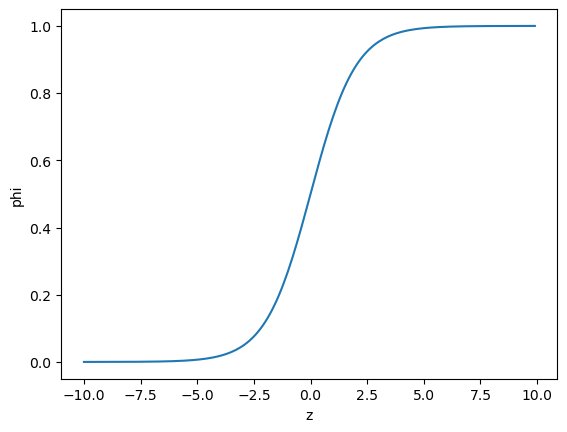

In [17]:
z =  np.arange(-10, 10, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()


# 로지스틱 회귀를 이용한 이진 분류

In [18]:
char_arr = np.array(['A','B','C','D','E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [19]:
bs_indexes = (train_target=='Bream') | (train_target=='Smelt')
print(bs_indexes)

[False  True False False False False False False False False  True False
 False False  True False False False False False False False False False
  True False False  True  True  True  True False False False  True False
 False False False False False False  True False False False False False
 False False False  True False  True False False False  True  True False
  True False False False False  True  True  True False False False  True
 False  True False False False False False False False  True  True False
 False  True False  True False False False  True False False  True False
 False False  True  True False False False False  True False False False
 False False  True False False False  True False False False  True]


In [20]:
train_bs = train_input[bs_indexes]
target_bs = train_target[bs_indexes]

In [21]:
print(train_bs.shape, target_bs.shape)

(32, 5) (32,)


In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lr = LogisticRegression()
lr.fit(train_bs, target_bs)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
print(lr.predict(train_bs[:5]))

['Bream' 'Bream' 'Bream' 'Bream' 'Smelt']


In [25]:
print(target_bs[:5])

['Bream' 'Bream' 'Bream' 'Bream' 'Smelt']


## 로지스틱 회귀 계수 확인

In [26]:
print(lr.coef_, lr.intercept_)

[[-0.41036912 -0.57228354 -0.64216513 -0.90299219 -0.73648258]] [-2.1861111]


## $$-{(y\log(p) + (1 - y)\log(1 - p))} $$


# 로지스틱 회귀로 다중 분류 수행하기


###  이진 분류기를 활용하여 다중 클래스 분류 가능
    * 일대다(OvR 또는 OvA)
    * 일대일(OvO)

### 일대다 방식 활용 예제
    * 숫자 5 예측하기에서 사용했던 이진 분류 방식을 동일하게 모든 숫자에 대해서 실행
    * 각 샘플에 대해 총 10번 각기 다른 이진 분류기를 실행
    * 이후 각 분류기의 결정 점수 중에서 가장 높은 점수를 받은 클래스를 해당 샘플의 클래스로 선택

### 일대일 방식 활용 예제
    * 조합 가능한 모든 클래스 일대일 분류 방식을 진행하여 가장 많은 결투(duell)를 이긴 숫자를 선택
    * MNIST의 경우, 0과 1 구별, 0과 2 구별, ..., 1과 2 구별, 1과 3 구별, ..., 8과 9 구별 등 
        (9+8+...+1 = 45)개의 결투를 판별하는 45개의 분류기 활용.
        단, 각 결투에 해당되는 데이터 샘플만 훈련에 사용됨.
    * 각각의 훈련 샘플에 대해 가장 많은 결투를 이긴 숫자의 클래스를 예측값으로 사용함.
        예를 들어, 숫자 1이 9번의 결투를 모두 이기면 숫자 1을 예측값으로 지정함.

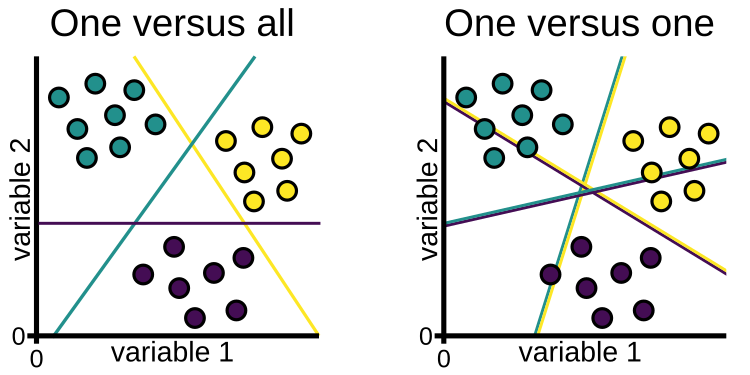

In [27]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_input, train_target)
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))


0.9411764705882353
0.9


In [28]:
lr.predict(test_input[:5])

array(['Smelt', 'Perch', 'Bream', 'Perch', 'Perch'], dtype=object)

In [29]:
test_target[:5]

array(['Smelt', 'Smelt', 'Bream', 'Perch', 'Perch'], dtype=object)

In [30]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [31]:
proba = lr.predict_proba(test_input[:5])
print(np.round(proba, decimals=2))

[[0.   0.   0.12 0.   0.02 0.86 0.  ]
 [0.   0.01 0.47 0.   0.09 0.43 0.  ]
 [0.98 0.01 0.   0.   0.   0.   0.01]
 [0.   0.03 0.62 0.   0.12 0.23 0.01]
 [0.   0.   0.93 0.   0.05 0.   0.02]]


In [32]:
print(lr.coef_, lr.intercept_)

[[-1.4259559  -0.88290954  2.31955279  7.78448878 -0.38450484]
 [-0.41154175 -1.93108774 -3.10891015  6.51290148 -1.90533329]
 [ 3.14513195  6.68121475 -9.36354125 -6.8854816   5.30771612]
 [-0.08103429  3.60486638  3.77242684 -3.3251622  -1.8785657 ]
 [-2.68942086 -6.20203204  5.11462921 -1.34041507  2.97190455]
 [-0.52787291  0.39132251  0.60453885 -3.30405246 -5.14570811]
 [ 1.99069377 -1.66137431  0.66130371  0.55772108  1.03449128]] [-0.32597956 -0.18956881  2.77731845 -0.12028881  1.81792579 -6.90098242
  2.94157535]
